<a href="https://colab.research.google.com/github/fariya09ahmed-commits/Fariya-Ahmed/blob/main/paper11_dengue_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [155]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

## Import the CSV Data as Pandas DataFrame

In [156]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [157]:
df = pd.read_csv('/content/drive/MyDrive/paper1 data dengue detenction hematological data set.csv')

## Show Top 5 Records

In [158]:
df.head()

,Gender,Age,Hemoglobin(g/dl),Neutrophils(%),Lymphocytes(%),Monocytes(%),Eosinophils(%),RBC,HCT(%),MCV(fl),MCH(pg),MCHC(g/dl),RDW-CV(%),Total Platelet Count(/cumm),MPV(fl),PDW(%),PCT(%),Total WBC count(/cumm),Result
0,Male,21,14.8,48,47,3,2,5,48.00,96.0,29.60,30.8,11.6,112000,10.70,15.40,0.120,5100,positive
1,Male,30,15.0,47,49,6,3,5,49.80,96.1,28.40,29.5,11.8,96000,10.60,15.80,0.121,4500,positive
2,Male,51,16.3,41,48,4,5,5,50.10,93.5,31.30,32.7,13.5,184000,10.40,16.40,0.130,6000,negative
3,Female,26,12.3,46,49,7,5,5,44.00,90.0,30.50,30.5,14.7,167000,8.10,17.10,0.110,5000,negative
4,Male,35,16.1,45,46,4,4,5,50.53,91.0,29.12,29.2,15.2,155000,10.52,12.34,0.150,4600,negative


## Shape of the dataset

In [159]:
df.shape

(1523, 19)

## Check Missing values

In [160]:
df.isna().sum() /len(df)*100

,0
Gender,0.0
Age,0.0
Hemoglobin(g/dl),0.0
Neutrophils(%),0.0
Lymphocytes(%),0.0
Monocytes(%),0.0
Eosinophils(%),0.0
RBC,0.0
HCT(%),0.0
MCV(fl),0.0


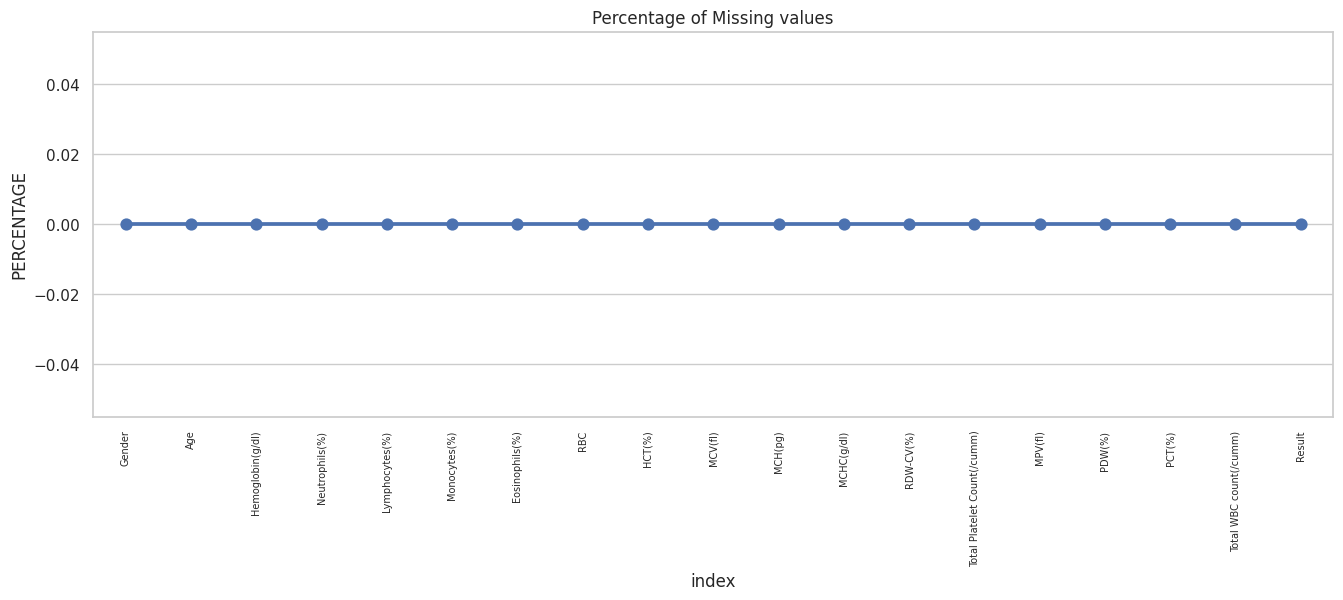

In [161]:
missing = pd.DataFrame((df.isnull().sum())*100/df.shape[0]).reset_index()
plt.figure(figsize=(16,5))
ax = sns.pointplot(x='index',y=0,data=missing)
plt.xticks(rotation =90,fontsize =7)
plt.title("Percentage of Missing values")
plt.ylabel("PERCENTAGE")
plt.show()

## Check Duplicates

In [162]:
df.duplicated().sum()

np.int64(12)

## Check data types

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1523 entries, 0 to 1522
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       1523 non-null   object 
 1   Age                          1523 non-null   int64  
 2   Hemoglobin(g/dl)             1523 non-null   float64
 3   Neutrophils(%)               1523 non-null   int64  
 4   Lymphocytes(%)               1523 non-null   int64  
 5   Monocytes(%)                 1523 non-null   int64  
 6   Eosinophils(%)               1523 non-null   int64  
 7   RBC                          1523 non-null   int64  
 8   HCT(%)                       1523 non-null   float64
 9   MCV(fl)                      1523 non-null   float64
 10  MCH(pg)                      1523 non-null   float64
 11  MCHC(g/dl)                   1523 non-null   float64
 12  RDW-CV(%)                    1523 non-null   float64
 13  Total Platelet Cou

### Checking the number of unique values of each column

In [164]:
df.nunique()

,0
Gender,2
Age,67
Hemoglobin(g/dl),221
Neutrophils(%),27
Lymphocytes(%),26
Monocytes(%),8
Eosinophils(%),8
RBC,4
HCT(%),829
MCV(fl),201



## Check statistics of data set

In [165]:
df.describe()

,Age,Hemoglobin(g/dl),Neutrophils(%),Lymphocytes(%),Monocytes(%),Eosinophils(%),RBC,HCT(%),MCV(fl),MCH(pg),MCHC(g/dl),RDW-CV(%),Total Platelet Count(/cumm),MPV(fl),PDW(%),PCT(%),Total WBC count(/cumm)
count,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000
mean,40.310571,14.513451,44.484570,43.559422,3.270519,3.083388,4.765594,45.189280,89.815561,29.897225,32.050271,13.635792,173127.170716,9.588806,15.312966,0.289080,5483.024951
std,15.286190,1.627142,4.344736,4.972815,1.209507,1.000791,0.722874,3.566435,5.515619,2.026022,1.551697,1.430746,64832.681751,0.848706,1.405457,5.992864,1137.344040
min,5.000000,10.400000,29.000000,29.000000,2.000000,1.000000,4.000000,36.300000,80.000000,22.900000,27.080000,11.000000,56000.000000,7.500000,8.400000,0.000020,3500.000000
25%,28.000000,13.200000,42.000000,41.000000,2.000000,2.000000,4.000000,42.595000,85.100000,28.400000,30.900000,12.400000,114907.000000,8.900000,14.230000,0.106000,4626.000000
50%,39.000000,14.600000,45.000000,44.000000,3.000000,3.000000,5.000000,45.550000,89.700000,30.000000,32.000000,13.800000,167385.000000,9.660000,15.260000,0.141000,5397.000000
75%,53.000000,15.800000,48.000000,47.000000,4.000000,4.000000,5.000000,47.840000,94.200000,31.400000,33.200000,14.700000,228649.500000,10.283000,16.400000,0.173000,6131.500000
max,78.000000,17.500000,60.000000,56.000000,9.000000,9.000000,7.000000,51.980000,100.000000,34.000000,35.000000,21.330000,299803.000000,11.235000,17.990000,234.000000,14900.000000


In [166]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['Gender'].unique())
print("Categories in 'result' variable:     ",end=" " )
print(df['Result'].unique())

Categories in 'gender' variable:      ['Male' 'Female']
Categories in 'result' variable:      ['positive' 'negative']


## Exploring Data ( Visualization )

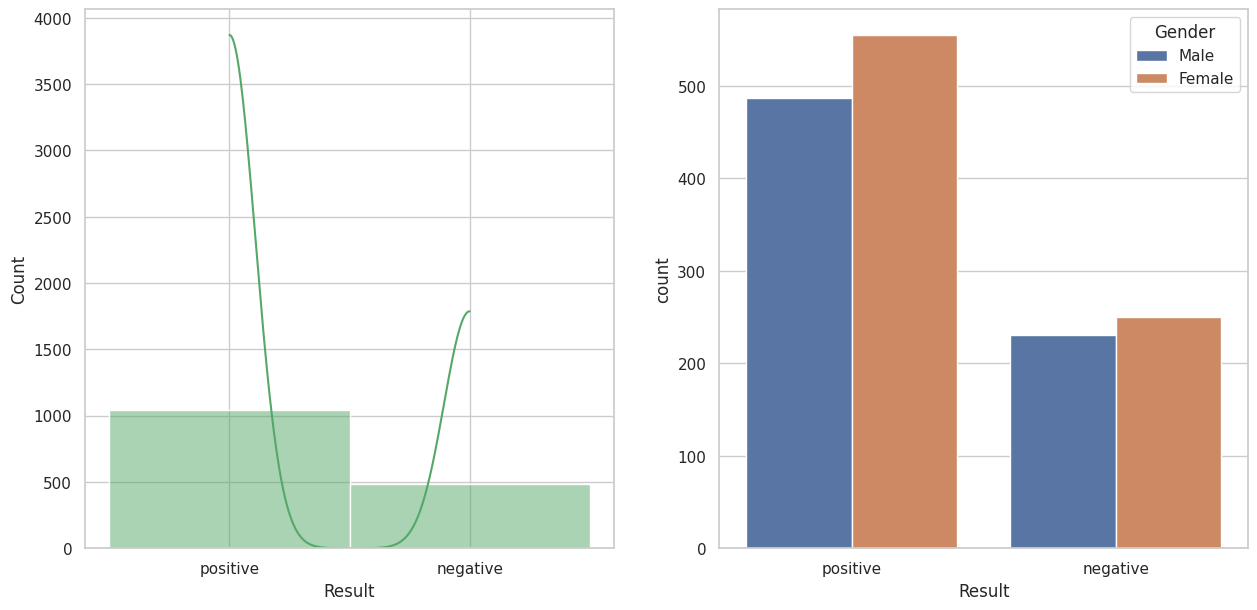

In [167]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='Result',bins=30,kde=True,color='g')
plt.subplot(122)
sns.countplot(data=df,x='Result',hue='Gender')
plt.show()

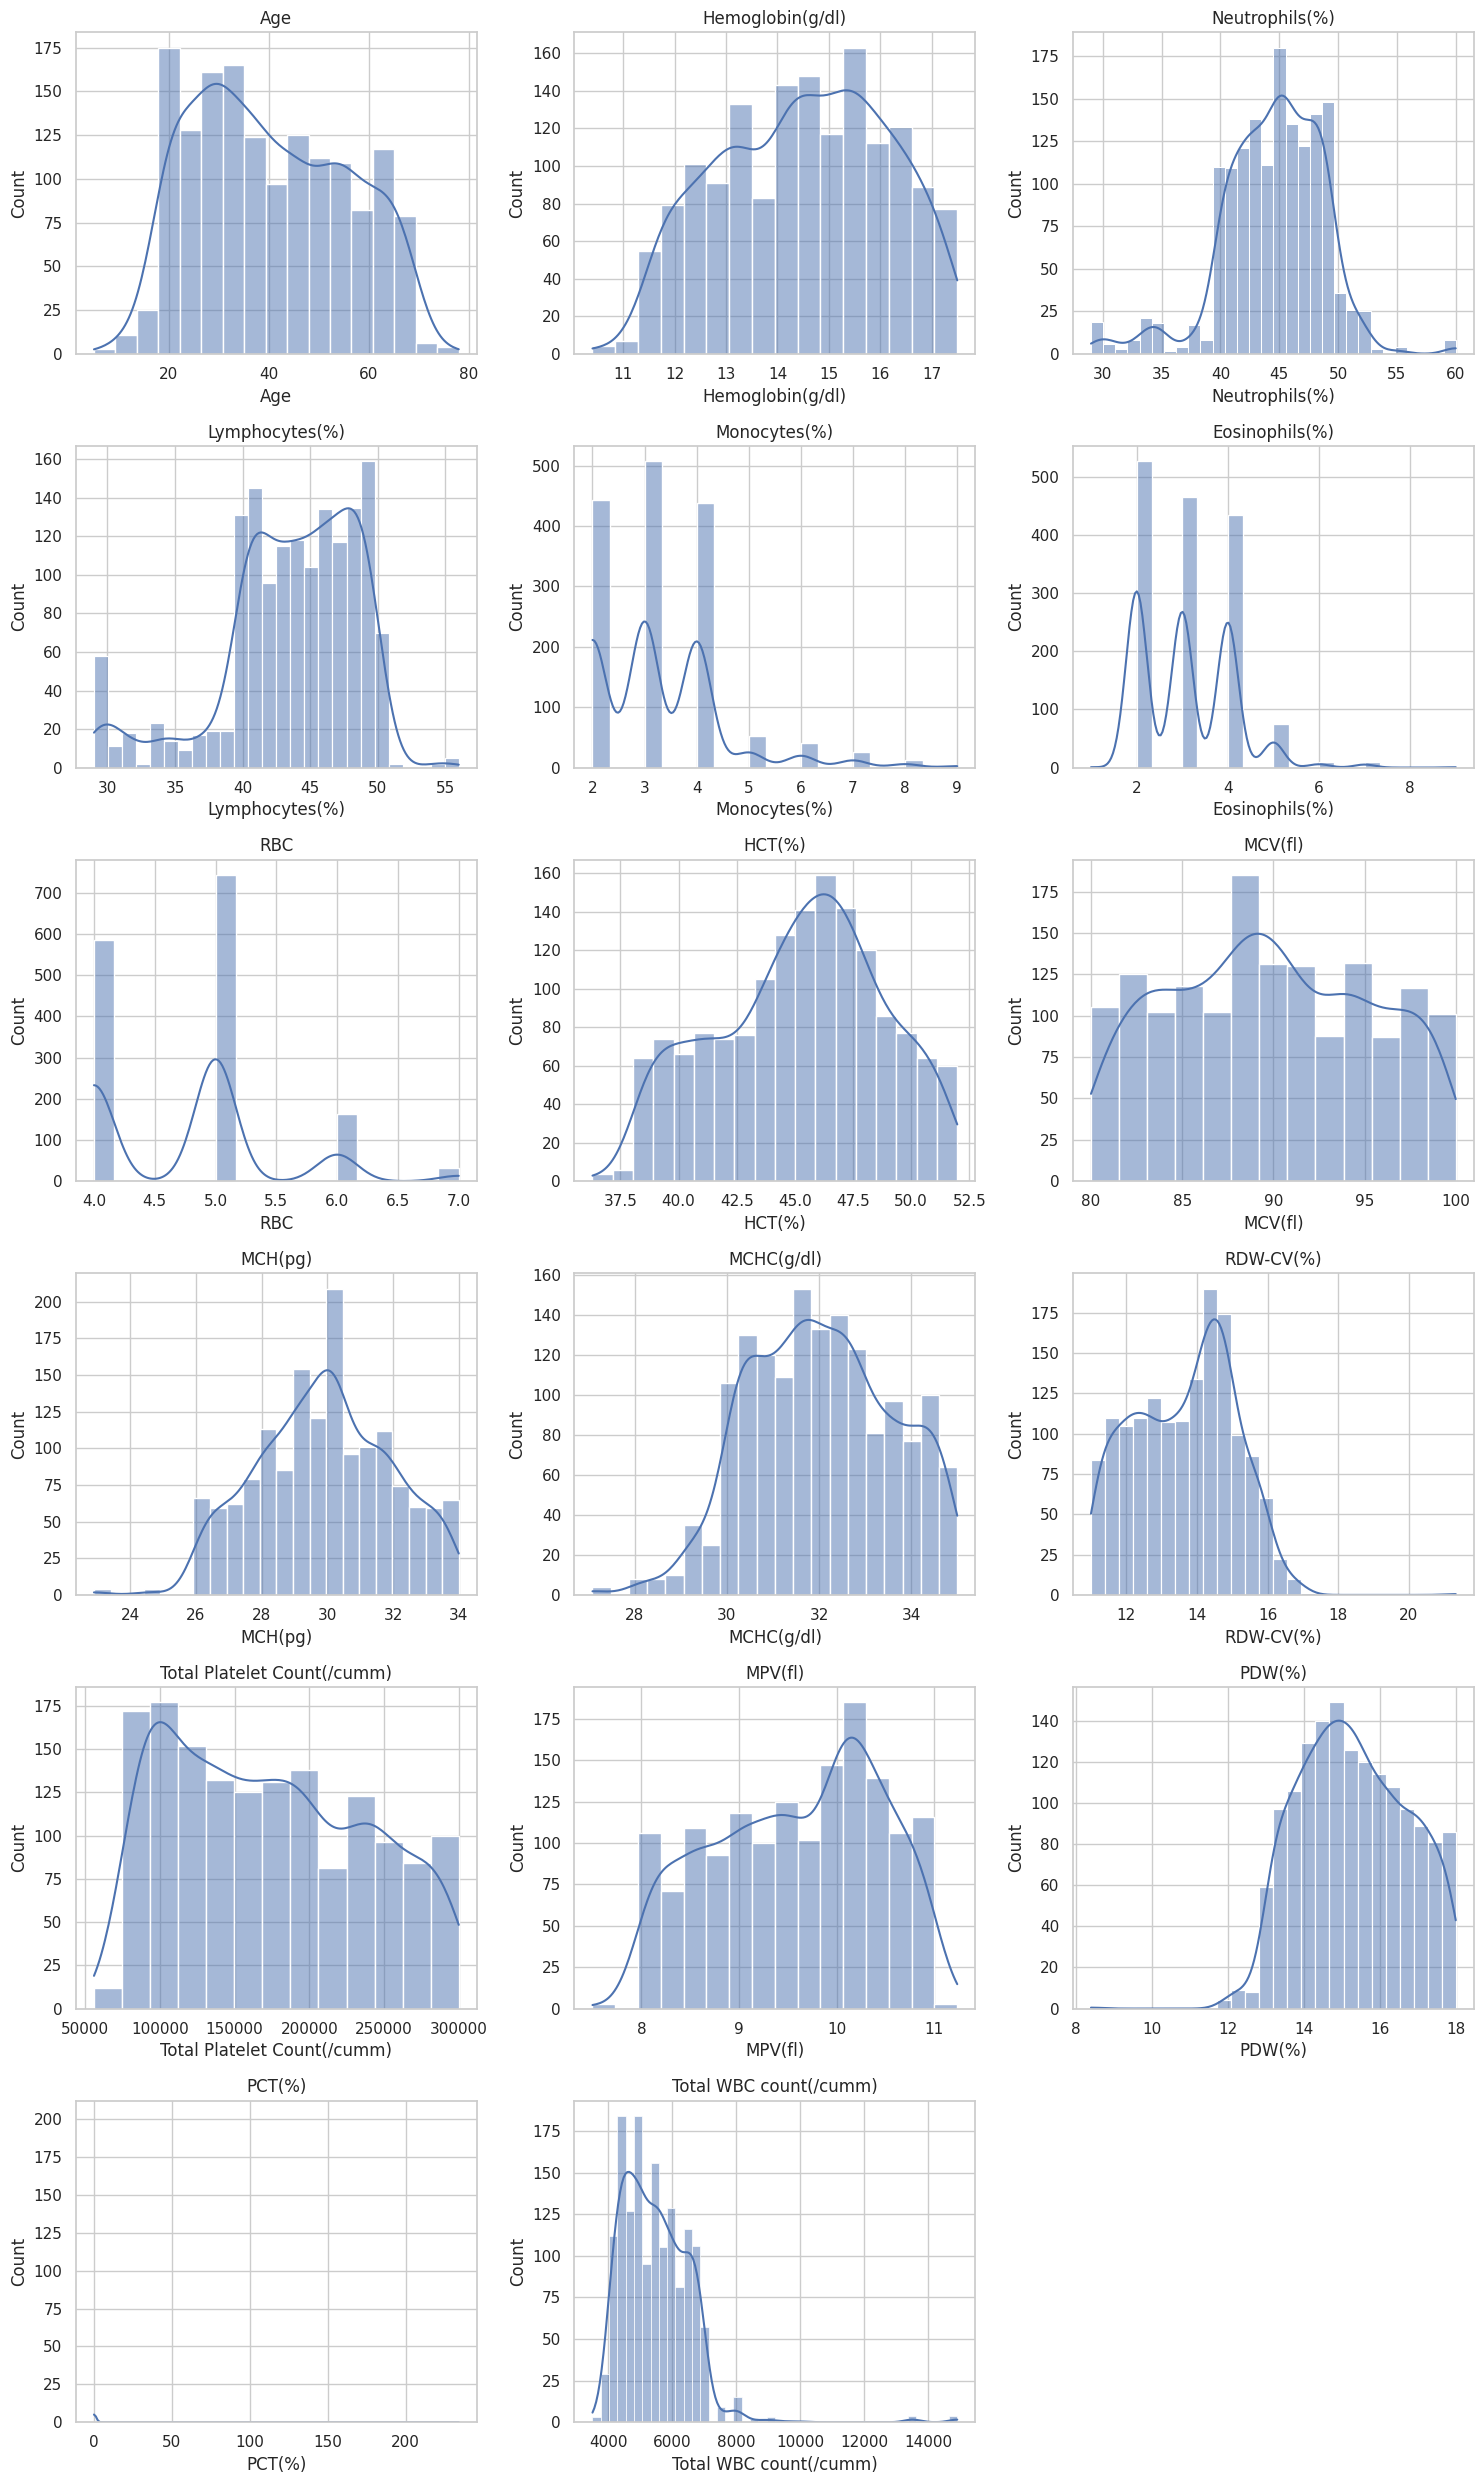

In [168]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 25))

for i, col in enumerate(numerical_columns):
    plt.subplot(6, 3, i + 1) # Changed to 6 rows, 3 columns
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [169]:
df.columns

Index(['Gender', 'Age', 'Hemoglobin(g/dl)', 'Neutrophils(%)', 'Lymphocytes(%)',
       'Monocytes(%)', 'Eosinophils(%)', 'RBC', 'HCT(%)', 'MCV(fl)', 'MCH(pg)',
       'MCHC(g/dl)', 'RDW-CV(%)', 'Total Platelet Count(/cumm)', 'MPV(fl)',
       'PDW(%)', 'PCT(%)', 'Total WBC count(/cumm)', 'Result'],
      dtype='object')

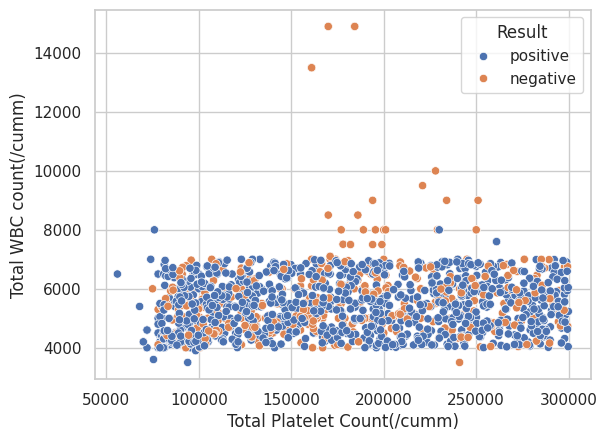

In [170]:
sns.scatterplot(x='Total Platelet Count(/cumm)', y='Total WBC count(/cumm)',hue='Result', data=df)
plt.show()

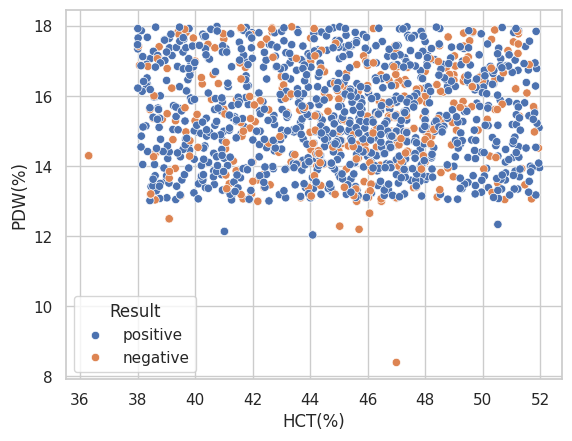

In [171]:
sns.scatterplot(x='HCT(%)', y='PDW(%)',hue='Result', data=df)
plt.show()

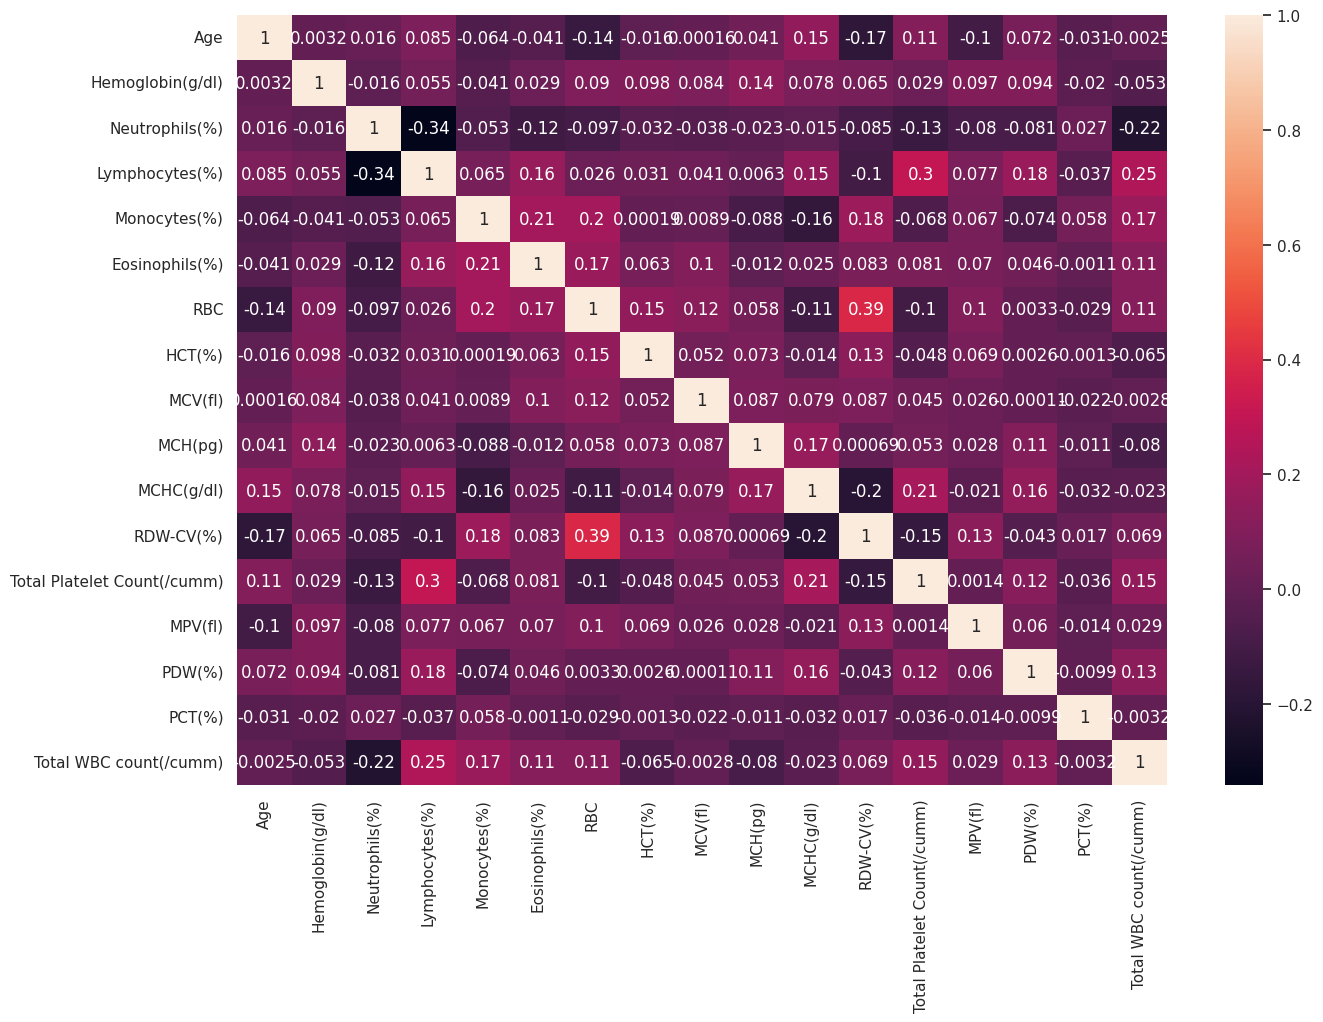

In [172]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## Label Encoded

In [173]:
from sklearn.preprocessing import LabelEncoder

# Instantiate the LabelEncoder
label_encoded = LabelEncoder()


df['Gender'] = label_encoded.fit_transform(df['Gender'])
print("\nAfter Label Encoding 'Gender':")
print(df[['Gender']])
#female=0, male=1

# Convert 'Result' column
df['Result'] = label_encoded.fit_transform(df['Result'])
print("\nAfter Label Encoding 'Result':")
print(df[['Result']])
# negative = 0, positive= 1


After Label Encoding 'Gender':
      Gender
0          1
1          1
2          1
3          0
4          1
...      ...
1518       0
1519       1
1520       1
1521       1
1522       1

[1523 rows x 1 columns]

After Label Encoding 'Result':
      Result
0          1
1          1
2          0
3          0
4          0
...      ...
1518       1
1519       1
1520       1
1521       1
1522       1

[1523 rows x 1 columns]


In [174]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## **Train and Test Split**

In [175]:
# Define features (X) and target (y)
X = df.drop('Result', axis=1)
y = df['Result']

# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("✅ Data Split:")
print(f"   Training: {X_train.shape[0]} patients ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Testing:  {X_test.shape[0]} patients ({X_test.shape[0]/len(df)*100:.0f}%)")
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

✅ Data Split:
   Training: 1218 patients (80%)
   Testing:  305 patients (20%)
(1218, 18)
(305, 18)
(1218,)
(305,)


## **Standar Scaling**

In [176]:
# Feature Scaling (IMPORTANT for KNN!)
print("⚙️ Scaling features...\n")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed!")

⚙️ Scaling features...

✅ Feature scaling completed!


## Outlier

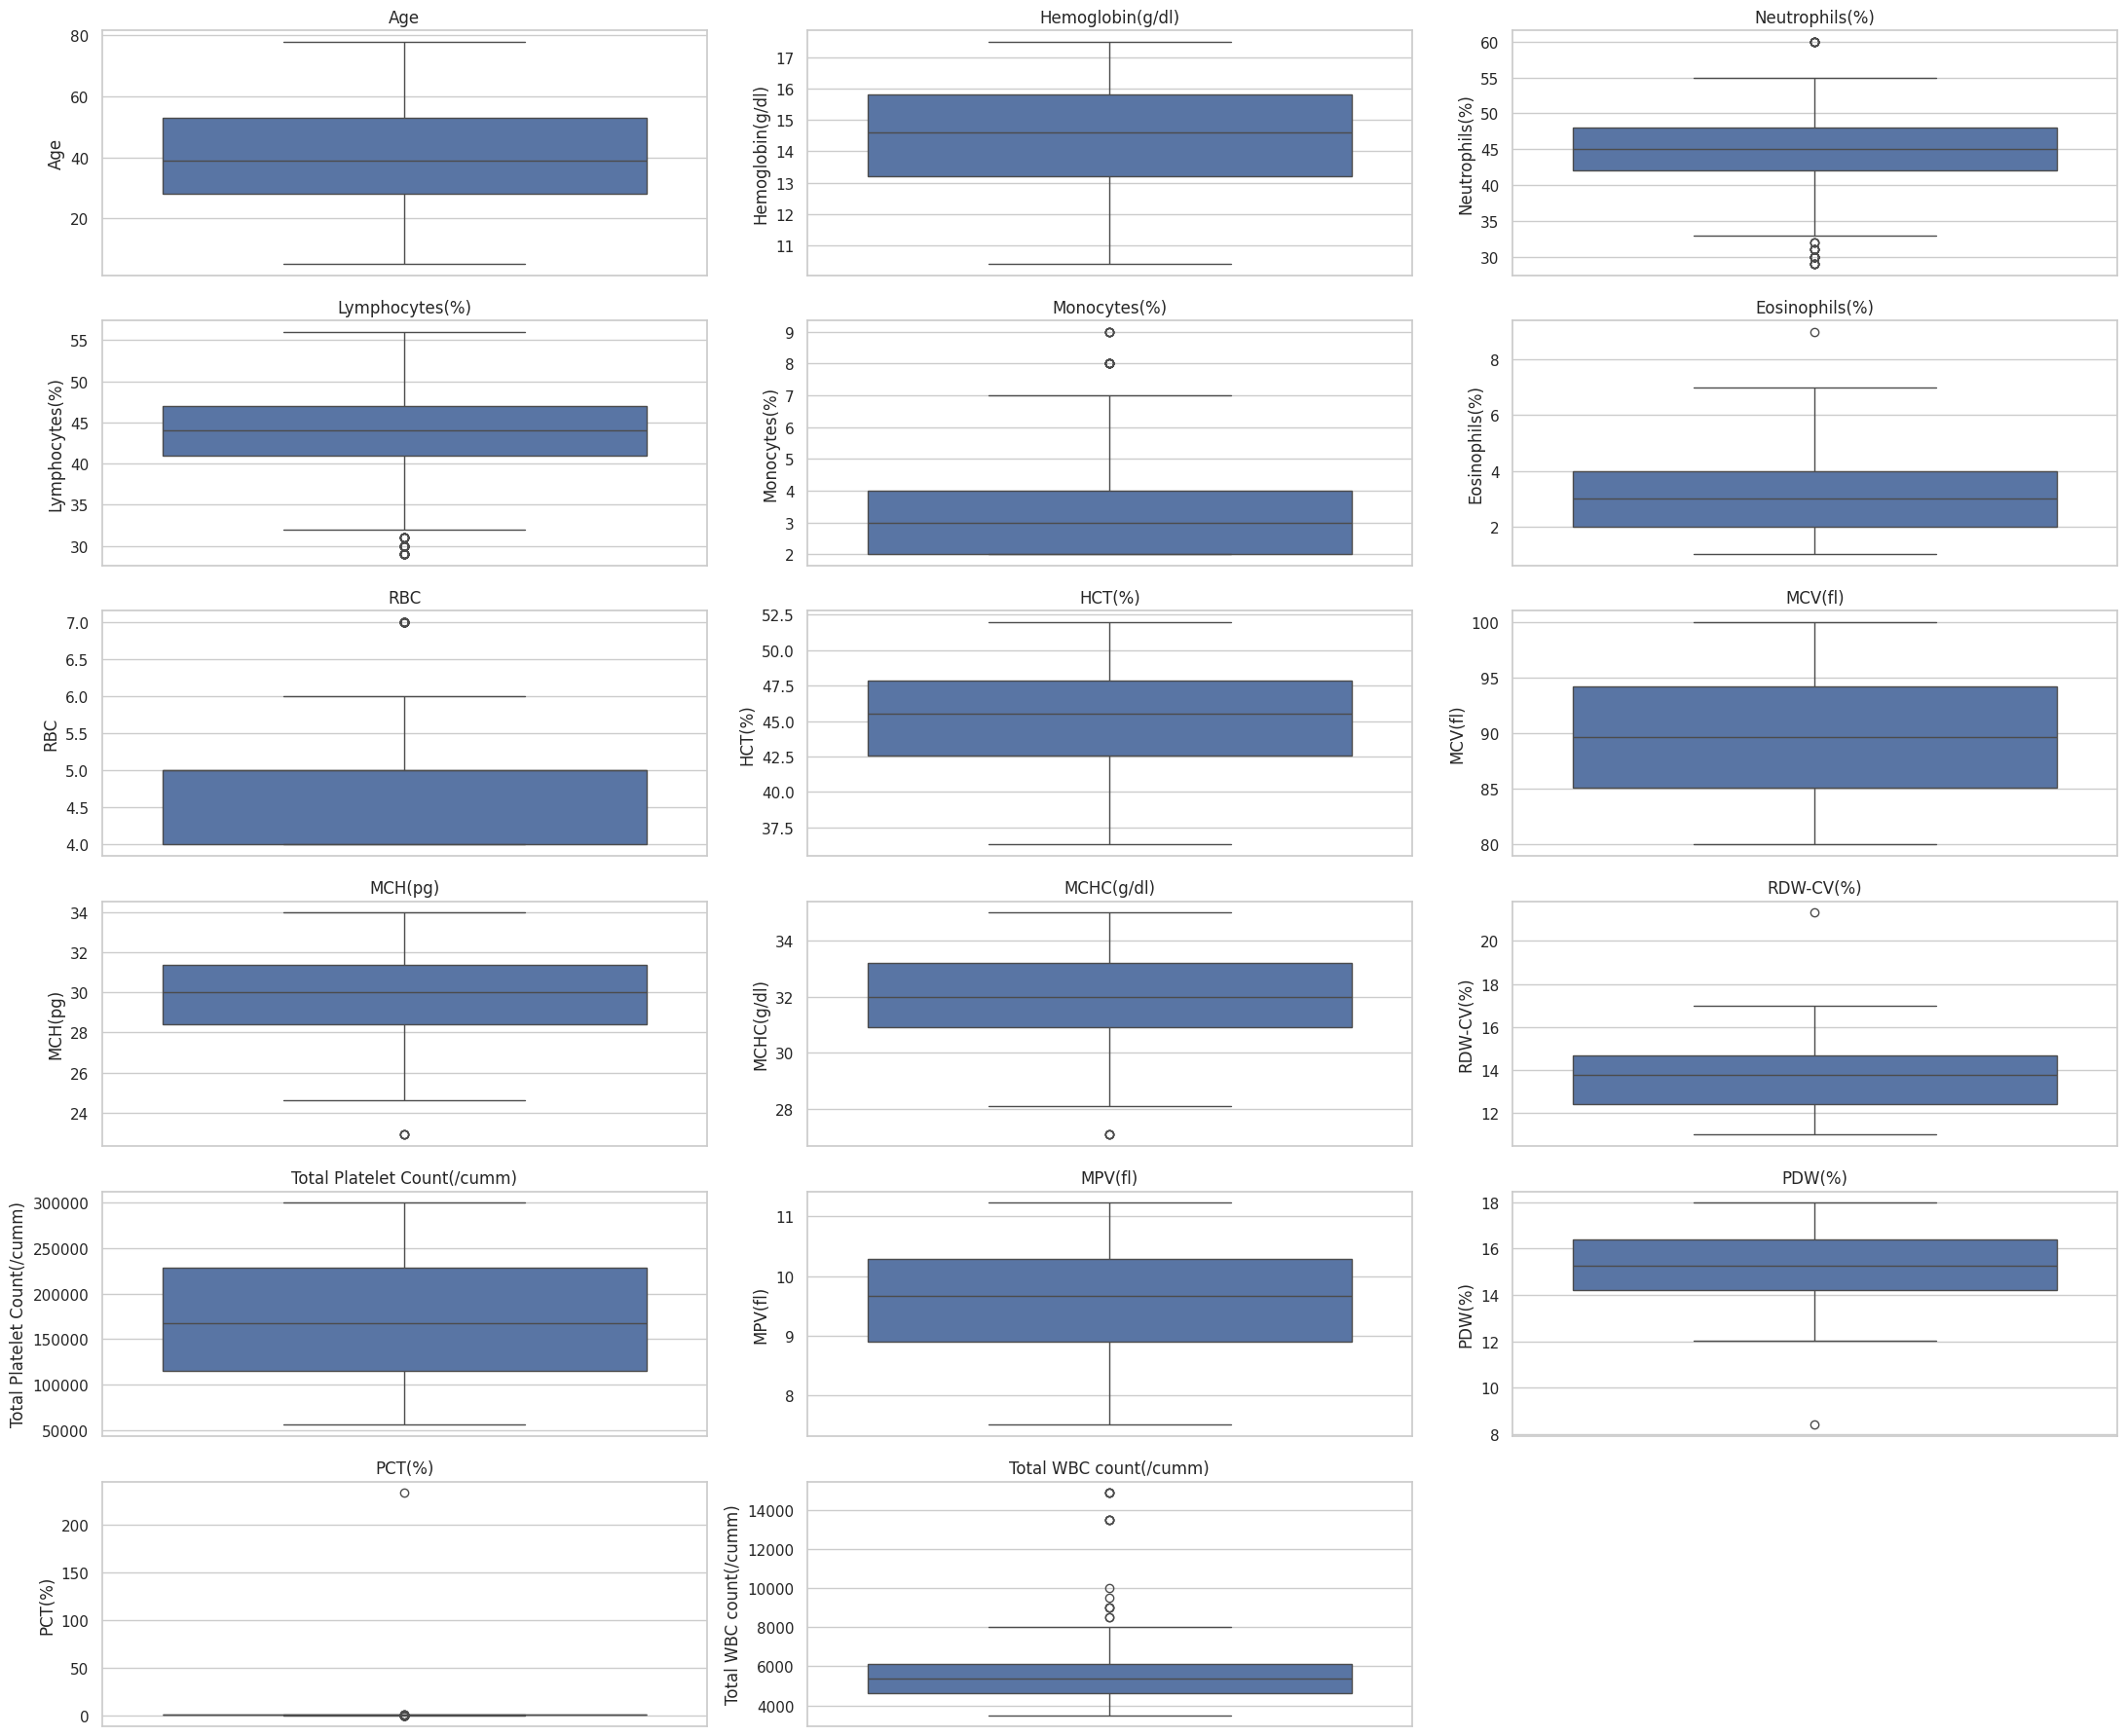

In [177]:
plt.figure(figsize=(22, 18))
for i, col in enumerate(numerical_columns):
    plt.subplot(6, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## Outlier removal

In [178]:
cols = ['Neutrophils(%)','Lymphocytes(%)','Monocytes(%)','Eosinophils(%)','RBC','MCH(pg)','MCHC(g/dl)', 'RDW-CV(%)', 'RDW-CV(%)','PDW(%)',]

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df[cols] < (Q1 - 1.5 * IQR)) |
                (df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]



In [179]:
print("Before:", df.shape[0])
print("After:", df_clean.shape[0])
print("Removed:", df.shape[0] - df_clean.shape[0])

Before: 1523
After: 1372
Removed: 151


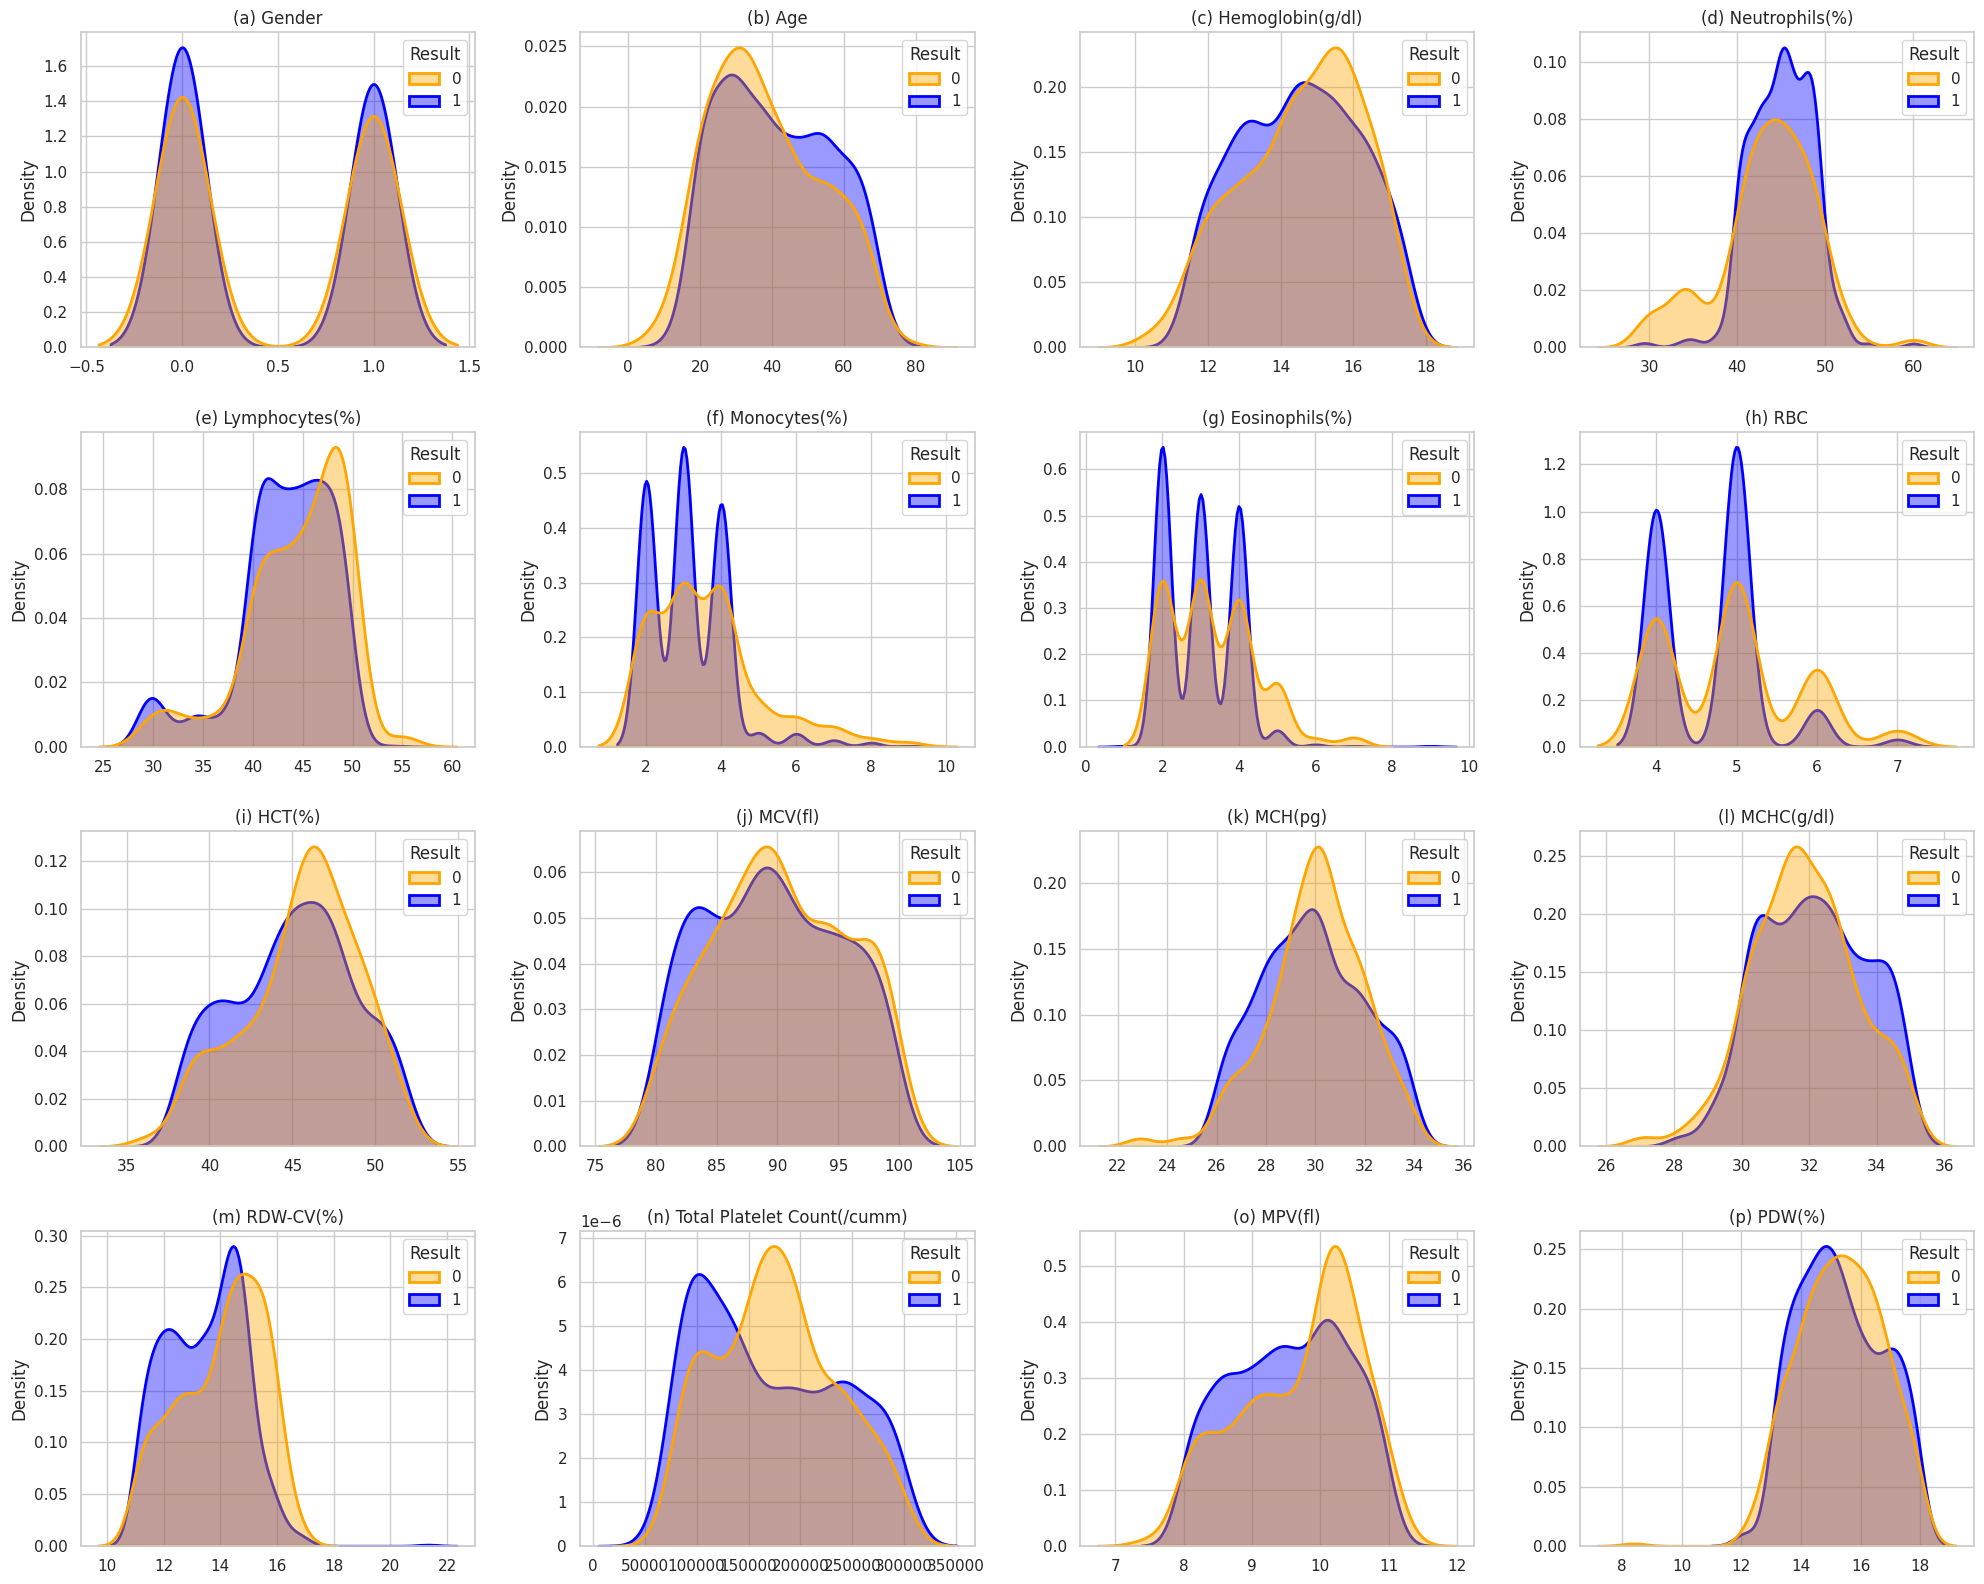

In [180]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
# Purple (Class 1) and Yellow/Orange (Class 0)
palette = {0: "orange", 1: "blue"}

# 2. Subplots toiri kora (4x4 grid)
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

columns = [
    'Gender', 'Age', 'Hemoglobin(g/dl)', 'Neutrophils(%)',
    'Lymphocytes(%)', 'Monocytes(%)', 'Eosinophils(%)', 'RBC',
    'HCT(%)', 'MCV(fl)', 'MCH(pg)', 'MCHC(g/dl)',
    'RDW-CV(%)', 'Total Platelet Count(/cumm)', 'MPV(fl)', 'PDW(%)'
]

for i, col in enumerate(columns):
    sns.kdeplot(
        data=df,
        x=col,
        hue='Result',
        fill=True,
        palette=palette,
        alpha=0.4,
        linewidth=2,
        ax=axes[i],
        common_norm=False
    )

    axes[i].set_title(f'({chr(97+i)}) {col}')
    axes[i].set_ylabel('Density')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

Result
1    1042
0     481
Name: count, dtype: int64


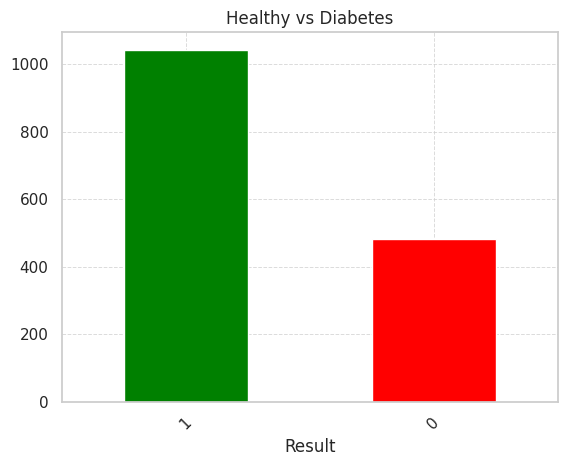

In [181]:
# Show distribution
print(df['Result'].value_counts())

# Plot
df['Result'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Healthy vs Diabetes')
plt.xticks([0, 1], rotation=45)
plt.grid(True,which="both", linestyle="--",linewidth=0.7, alpha=0.7)

In [182]:
df['Result'].value_counts()

,count
Result,
1,1042
0,481


## Cross Validation

In [183]:
# Create model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

model = LogisticRegression(max_iter=1000)
# Do 10-fold cross-validation
scores = cross_val_score(
    model,           # Our model
    X_train_scaled,  # Training data
    y_train,         # Training labels
    cv=5            # 5 mini-tests
)

print("5 mini-test scores:")
for i in range(5):
    print(f"  Test {i+1}: {scores[i]:.1%}")

print(f"\nAverage: {scores.mean():.1%}")
print(f"This means our model is {scores.mean():.1%} accurate!")

5 mini-test scores:
  Test 1: 70.1%
  Test 2: 74.2%
  Test 3: 70.9%
  Test 4: 72.0%
  Test 5: 75.7%

Average: 72.6%
This means our model is 72.6% accurate!


## Smoteenn

In [184]:
from imblearn.combine import SMOTEENN

# Class balancing
smote_enn = SMOTEENN(random_state=42)
X_train_bal, y_train_bal = smote_enn.fit_resample(X_train_scaled, y_train)
print(f"After SMOTEENN: {X_train_bal.shape}, positive: {sum(y_train_bal==1)}, negative: {sum(y_train_bal==0)}")

After SMOTEENN: (893, 18), positive: 298, negative: 595


## KNN Model

Best K: 11


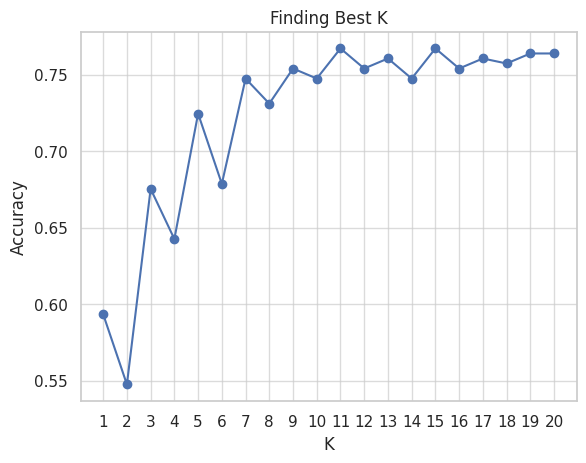

In [185]:
# Find best K
accuracies = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

best_k = accuracies.index(max(accuracies)) + 1
print(f"Best K: {best_k}")

# Plot
plt.plot(range(1, 21), accuracies, marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(range(1, 21))
plt.title('Finding Best K')
plt.grid(alpha=0.7)

plt.show()

In [186]:
# Train final KNN model
print(f"\n🤖 Training KNN with K = {best_k}...\n")

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("✅ KNN Model trained!")
print(f"\n📊 KNN Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)")


🤖 Training KNN with K = 11...

✅ KNN Model trained!

📊 KNN Accuracy: 0.7672 (76.72%)



📋 KNN Classification Report:
              precision    recall  f1-score   support

     Healthy       0.71      0.39      0.50        92
    Diabetes       0.78      0.93      0.85       213

    accuracy                           0.77       305
   macro avg       0.74      0.66      0.68       305
weighted avg       0.76      0.77      0.74       305



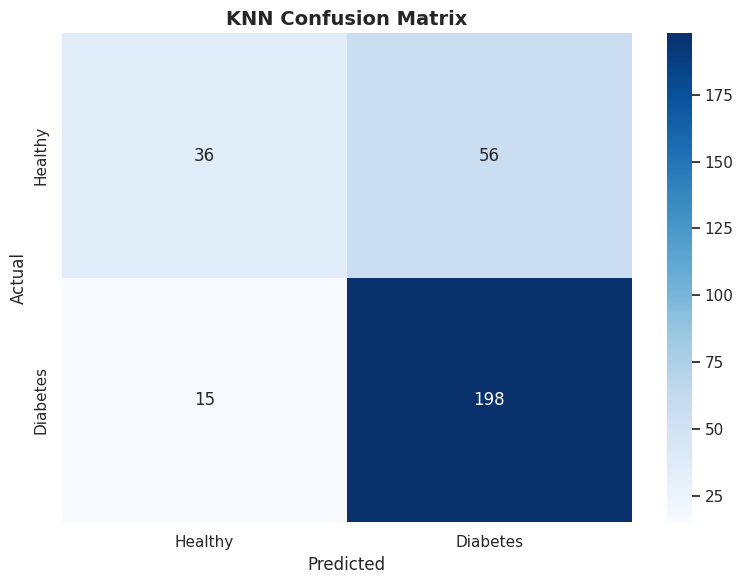

In [187]:
# Evaluation
print("\n📋 KNN Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_knn, target_names=['Healthy', 'Diabetes']))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Diabetes'],
            yticklabels=['Healthy', 'Diabetes'])
plt.title('KNN Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*60)

## Decision Tree

In [188]:
# Train Decision Tree
print("🌳 Training Decision Tree...\n")

dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,          # Limit depth to avoid overfitting
    min_samples_split=5,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train, y_train)  # No scaling needed
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("✅ Decision Tree trained!")
print(f"\n📊 Decision Tree Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")

🌳 Training Decision Tree...

✅ Decision Tree trained!

📊 Decision Tree Accuracy: 0.7639 (76.39%)



📋 Decision Tree Classification Report:
              precision    recall  f1-score   support

     Healthy       0.74      0.34      0.46        92
    Diabetes       0.77      0.95      0.85       213

    accuracy                           0.76       305
   macro avg       0.75      0.64      0.66       305
weighted avg       0.76      0.76      0.73       305



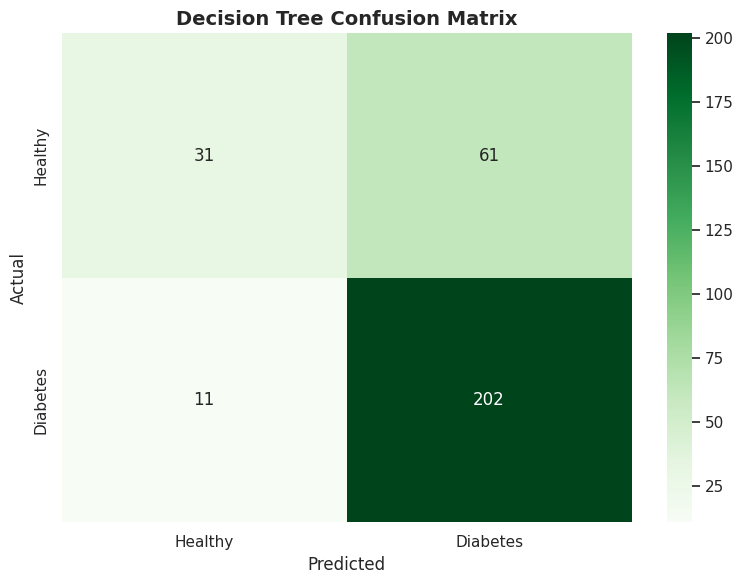

In [189]:
# Evaluation
print("\n📋 Decision Tree Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_dt, target_names=['Healthy', 'Diabetes']))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy', 'Diabetes'],
            yticklabels=['Healthy', 'Diabetes'])
plt.title('Decision Tree Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*60)

## Random Forest

In [190]:
# Train Random Forest
print("🌲🌳🌲 Training Random Forest...\n")

rf_model = RandomForestClassifier(
    n_estimators=300,     # 100 trees
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1             # Use all CPU cores
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("✅ Random Forest trained!")
print(f"   → {rf_model.n_estimators} trees created")
print(f"   → Each tree votes")
print(f"\n📊 Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

🌲🌳🌲 Training Random Forest...

✅ Random Forest trained!
   → 300 trees created
   → Each tree votes

📊 Random Forest Accuracy: 0.7607 (76.07%)



📋 Random Forest Classification Report:
              precision    recall  f1-score   support

     Healthy       0.68      0.39      0.50        92
    Diabetes       0.78      0.92      0.84       213

    accuracy                           0.76       305
   macro avg       0.73      0.66      0.67       305
weighted avg       0.75      0.76      0.74       305



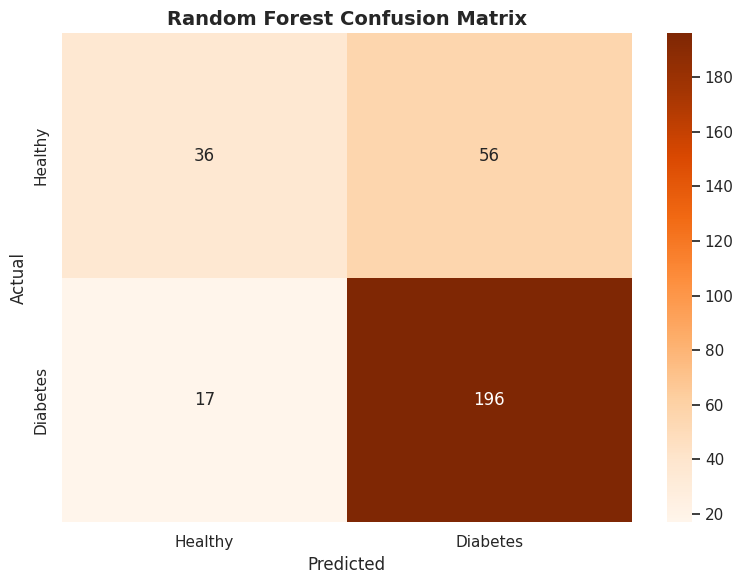

In [191]:
# Evaluation
print("\n📋 Random Forest Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=['Healthy', 'Diabetes']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Healthy', 'Diabetes'],
            yticklabels=['Healthy', 'Diabetes'])
plt.title('Random Forest Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*60)